# Wstęp

Zadanie nr 14 stanowi rozszerzenie wprowadzenia do zagadnienia głębokich modeli uczenia ze wzmocnieniem (*Deep Reinforcement Learning*, **DRL**), w którym omówione zostaną bardziej zaawansowane modele (w szczególności typu *policy gradient* oraz aktor-krytyk).

## Cel ćwiczenia

Celem ćwiczenia jest zapoznanie z:

* metodami *policy gradient* oraz aktor-krytyk w bibliotece *Stable-Baselines3*
* sposobem przygotowywania środowisk dla tego typu modeli
* dostępnymi hiperparametrami i modyfikacjami metod


## Metody *policy gradient*

W odróżnieniu od omawianych poprzednio metod głębokiego uczenia ze wzmocnieniem opartych na funkcjach wartości (gdzie uczymy się ewaluować akcje w dowolnym stanie), w przypadku *policy gradient* próbujemy bezpośrednio ustalić postać strategii optymalnej $\pi^*$. W tym celu stosujemy postać sparametryzowaną $\pi_\theta$, gdzie $\theta$ jest zbiorem parametrów aktualizowanych podczas uczenia:

$$\pi_\theta(\mathbf{s}, \mathbf{a}) = p(\mathbf{a} | \mathbf{s}, \theta)$$

Celem trenowania modelu strategii odbywać się będzie poprzez aktualizowanie parametrów w taki sposób, aby maksymalizować oczekiwaną wartość zwrotu. Uczenie może odbywać się na różne sposoby - w przypadku metod głębokiego uczenia ze wzmocnieniem, model strategii (sieć neuronową) trenować będziemy metodą gradientową.

Funkcja nagrody (której metody *policy gradient* używają jako funkcji celu) będzie zdefiniowana w następujący sposób:

$$\mathcal{L}(\theta) = \sum_{\mathbf{s}\in\mathbf{S}} d^\pi(\mathbf{s})V^\pi(\mathbf{s}) = \sum_{\mathbf{s}\in\mathbf{S}} d^\pi(\mathbf{s})\sum_{\mathbf{a}\in\mathbf{A}}\pi_\theta(\mathbf{a} | \mathbf{s}) Q^\pi(\mathbf{s}, \mathbf{a}),$$

gdzie $d^\pi(\mathbf{s})=\lim_{t\rightarrow\infty}p(\mathbf{s}_t=\mathbf{s}_0, \pi_\theta)$ jest rozkładem stanów *on-policy* przy strategii $\pi$) - prawdopodobieństwo, że w kroku czasowym $t$ uzyskamy stan $\mathbf{s}$ postępując według strategii $\pi_\theta$, $V^\pi(\mathbf{s})$ to funkcja wartości (oczekiwana wartość zwrotu), a $Q^\pi(\mathbf{s}, \mathbf{a})$ to funkcja jakości.

W literaturze występuje wiele metod uczenia  uczenia *policy gradient*. Jednym z aspektów rozróżniajacych je jest sposób obliczania całkowitej wartości zwrotu (w każdym kroku w środowisku, wykorzystując dotychczasową wartość nagród jako estymację funkcji jakości, lub np. przechodząc cały epizod w środowisku).

### Metody aktor-krytyk

Jedną z metod ustalania wartości funkcji jakości jest podejście **aktor-krytyk**. Wykorzystujemy nim dwa modele: **aktor** (model strategii) jest wykorzystywany do podejmowania akcji w środowisku, oraz **krytyk** (model funkcji jakości), służący do estymacji wartości funkcji jakości $Q$.

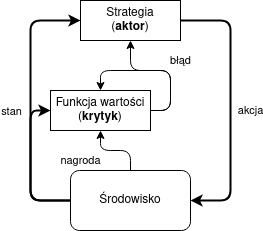

Trenowanie modelu aktor-krytyk polega na uczeniu parametrów $w$ funkcji wartości (krytyka) w celu poprawnego określania wartości zwrotu ($Q$ lub $V$) oraz trenowaniu modelu strategii $\pi_\theta(\mathbf{s}, \mathbf{a})$ (aktora) na podstawie sprzężenia zwrotnego dostarczanego przez krytyka, obserwującego i oceniającego podejmowane akcje. Algorytm dzałania wygląda następująco:

1. Zainicjalizuj stan początkowy $\mathbf{s}_1$, parametry aktora $\theta$ i krytyka $w$
2. Próbkuj akcję $\mathbf{a}_1 \sim \pi_\theta(\mathbf{a} | \mathbf{s})$
3. W każdym kroku czasowym $t = 1, 2, \dots, T$:
  1. Pobierz wartość nagrody $r_t$ i następny stan $\mathbf{s}_{t+1}$
  2. Próbkuj akcję w następnym kroku $\mathbf{a}_{t+1} \sim \pi_\theta(\mathbf{a}_{t+1} | \mathbf{s}_{t+1})$
  3. Zaktualizuj parametry strategii $\theta$ wg gradientu funkcji celu
  4. Zaktualizuj parametry funkcji wartości na podstawie błędu pomiędzy wartością funkcji $Q$ w kolejnym kroku, a sumą funkcji $Q$ z aktualnego oraz uzyskanej nagrody.

Najczęściej używa się dwóch współczynników uczenia: osobno dla trenowania aktora $\alpha_\theta$ oraz krytyka $\alpha_w$.


### A3C/A2C

Algorytmy A3C (*Asynchronous Advantage Actor-Critic*) i A2C (*Advantage Actor-Critic*) [[Mnih et al.](https://arxiv.org/abs/1602.01783)] to dwie wersje metody głębokiego uczenia ze wzmocnieniem oparte na architekturze aktor-krytyk. Metoda ta opiera się na wykorzystaniu wspólnej sieci neuronowej do predykcji akcji (model strategii) oraz ich ewaluacji (model funkcji wartości), przy użyciu odrębnych wyjść (*heads*). Podejście to bazuje na wykorzystaniu wielu agentów, oddziałujących z własną kopią środowiska przy użyciu indywidualnych zestawów wag sieci i uczących swoje kopie przez określony okres, a następnie synchronizujące się z globalną siecią asynchronicznie (A3C) lub synchronicznie (A2C).

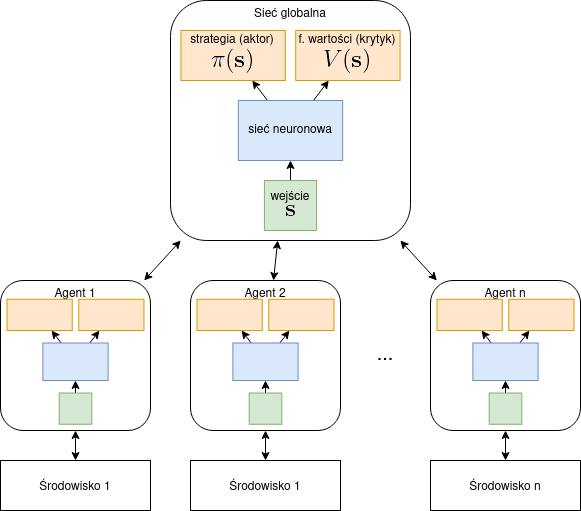

Dzięki zastosowaniu wielu agentów oddziałujących ze swoimi kopiami środowiska, oraz cyklicznemu synchronizowaniu wag z siecią globalną, trenowanie modelu może odbywać się na bardziej zróżnicowanym zbiorze doświadczeń, niż w przypadku pojedynczego agenta, a przez to model powinien zbiegać szybciej, do globalnego optimum bez wykorzystania *experience replay*.

Drugim z ulepszeń zastosowanych w tych metodach jest zastąpienie funkcji jakości $Q$ przez funkcję przewagi $A$. W tym podejściu, model krytyka, zamiast uczyć się wprost wartości funkcji jakości, próbujemy nauczyć się funkcji, która jest różnicą funkcji jakości i funkcji jakości:

$$A(\mathbf{s}, \mathbf{a}) = Q(\mathbf{s}, \mathbf{a}) - V(\mathbf{s})$$

Innymi słowy, chcemy obliczać, o ile lepszy/gorszy będzie wybór akcji $\mathbf{a}$ w stanie $\mathbf{s}$ i postępowanie dalej zgodnie ze strategią od postępowania zgodnie ze strategią bezpośrednio od stanu $\mathbf{s}$.


Podobnie jak poprzednio, skorzystamy z gotowej implementacji metody A3C/A2C z biblioteki [**Stable-Baselines3**](https://stable-baselines.readthedocs.io). Zaczniemy od powtórzenia eksperymentów w środowisku CartPole z poprzedniej listy.


In [42]:
!apt-get install -y xvfb python-opengl > /dev/null 2>&1
!pip install gymnasium[classic-control] pyvirtualdisplay stable-baselines3[extra] > /dev/null 2>&1


In [43]:
import os
import random

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib import animation
from pyvirtualdisplay import Display
from stable_baselines3 import A2C
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import plot_results, load_results
from stable_baselines3.a2c.policies import MlpPolicy

from IPython import display as ipythondisplay


SEED = 13
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

DISPLAY = Display(visible=0, size=(400, 300))
DISPLAY.start()


def visualize_model(model, max_steps=50, env=None):
    """Show how a model works in the environment."""
    env = env or model.get_env()
    obs = env.reset()
    # VecEnv.reset() returns obs only; raw gymnasium env returns (obs, info)
    if isinstance(obs, tuple):
        obs = obs[0]

    fig, ax = plt.subplots()
    frames = []
    done = False

    while not done:
        frames.append(env.render())          # mode set at make() time
        with torch.no_grad():
            action, _ = model.predict(obs)
        step_result = env.step(action)
        if len(step_result) == 5:            # raw gymnasium: obs, rew, terminated, truncated, info
            obs, reward, terminated, truncated, info = step_result
            done = terminated or truncated
        else:                                # VecEnv: obs, rew, done, info
            obs, reward, done, info = step_result
        if len(frames) >= max_steps:
            break

    anim = animation.FuncAnimation(
        fig=fig,
        func=lambda i: ax.imshow(frames[i]),
        frames=range(len(frames)),
        interval=100,
        blit=False,
    )
    plt.close()

    reward_avg, reward_std = evaluate_policy(model, env, n_eval_episodes=100)
    print(f"Reward in episode: {reward_avg:.2f} +/- {reward_std:.2f}")

    return anim.to_jshtml()



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Sprawdźmy, jakie parametry przyjmuje model A2C oraz jego model strategii (zwróćmy uwagę, że stosujemy strategie odpowiednie dla A2C!).

Zwróćmy uwagę, że implementacja A2C w stable-baselines3 przyjmuje jeden współczynnik uczenia `learnin_rate` (stosowany dla modelu strategii) - współczynnik dla funkcji wartości uzyskiwany jest przez przemnożenie przez parametr `vf_coef`. Z kolei interfejs `MlpPolicy` jest podobny do klasy przeznaczonej dla modelu DQN - szczególnie interesująca jest architektura sieci.


In [44]:
help(A2C)


Help on class A2C in module stable_baselines3.a2c.a2c:

class A2C(stable_baselines3.common.on_policy_algorithm.OnPolicyAlgorithm)
 |  A2C(policy: str | type[stable_baselines3.common.policies.ActorCriticPolicy], env: Union[gymnasium.core.Env, ForwardRef('VecEnv'), str], learning_rate: float | collections.abc.Callable[[float], float] = 0.0007, n_steps: int = 5, gamma: float = 0.99, gae_lambda: float = 1.0, ent_coef: float = 0.0, vf_coef: float = 0.5, max_grad_norm: float = 0.5, rms_prop_eps: float = 1e-05, use_rms_prop: bool = True, use_sde: bool = False, sde_sample_freq: int = -1, rollout_buffer_class: type[stable_baselines3.common.buffers.RolloutBuffer] | None = None, rollout_buffer_kwargs: dict[str, typing.Any] | None = None, normalize_advantage: bool = False, stats_window_size: int = 100, tensorboard_log: str | None = None, policy_kwargs: dict[str, typing.Any] | None = None, verbose: int = 0, seed: int | None = None, device: torch.device | str = 'auto', _init_setup_model: bool = True

In [45]:
help(MlpPolicy)


Help on class ActorCriticPolicy in module stable_baselines3.common.policies:

class ActorCriticPolicy(BasePolicy)
 |  ActorCriticPolicy(observation_space: gymnasium.spaces.space.Space, action_space: gymnasium.spaces.space.Space, lr_schedule: collections.abc.Callable[[float], float], net_arch: list[int] | dict[str, list[int]] | None = None, activation_fn: type[torch.nn.modules.module.Module] = <class 'torch.nn.modules.activation.Tanh'>, ortho_init: bool = True, use_sde: bool = False, log_std_init: float = 0.0, full_std: bool = True, use_expln: bool = False, squash_output: bool = False, features_extractor_class: type[stable_baselines3.common.torch_layers.BaseFeaturesExtractor] = <class 'stable_baselines3.common.torch_layers.FlattenExtractor'>, features_extractor_kwargs: dict[str, typing.Any] | None = None, share_features_extractor: bool = True, normalize_images: bool = True, optimizer_class: type[torch.optim.optimizer.Optimizer] = <class 'torch.optim.adam.Adam'>, optimizer_kwargs: dict[s

Zacznijmy od przetestowania niewytrenowanego modelu w środowisku.


In [46]:
!pip install 'shimmy>=2.0'

In [47]:
env = gym.make("CartPole-v1",render_mode="rgb_array")
model = A2C(MlpPolicy, env)
display(ipythondisplay.HTML(visualize_model(model)))


Reward in episode: 47.03 +/- 28.81


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Analogicznie do zadania 13, spróbujemy wytrenować najprostszy model A2C w celu porównania procesu trenowania i efektów z modelem DQN.

Using cpu device
Wrapping the env in a DummyVecEnv.
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 20.8     |
|    ep_rew_mean        | 20.8     |
| time/                 |          |
|    fps                | 635      |
|    iterations         | 100      |
|    time_elapsed       | 0        |
|    total_timesteps    | 500      |
| train/                |          |
|    entropy_loss       | -0.693   |
|    explained_variance | -0.0147  |
|    learning_rate      | 0.0001   |
|    n_updates          | 99       |
|    policy_loss        | 1.98     |
|    value_loss         | 10.4     |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 19.9     |
|    ep_rew_mean        | 19.9     |
| time/                 |          |
|    fps                | 610      |
|    iterations         | 200      |
|    time_elapsed       | 1        |
|    total_timesteps   

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Max reward: 500.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


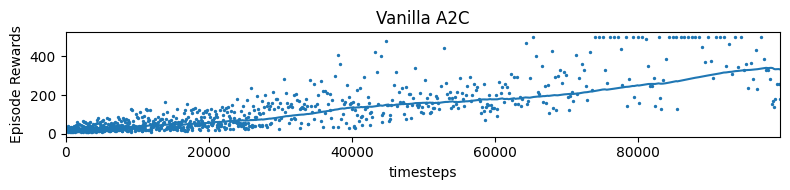

In [48]:
batch_size = 64
lr = 1e-4
total_timesteps = 100000

env = gym.make("CartPole-v1",render_mode="rgb_array")
log_dir = "/tmp/vanilla/"
os.makedirs(log_dir, exist_ok=True)  # we have to create this dir - it does not exist
env = Monitor(env, filename=log_dir)

vanilla_a2c = A2C(
    MlpPolicy, env, learning_rate=lr, seed=SEED,
    verbose=1,
)
vanilla_a2c.learn(total_timesteps)
display(ipythondisplay.HTML(visualize_model(vanilla_a2c)))
plot_results([log_dir], total_timesteps, "timesteps", "Vanilla A2C")
results = load_results(log_dir)
print(f"Max reward: {results.r.max()}")


Wyniki są lepsze niż najprostszy DQN, lecz uczenie trwa stosunkowo długo. Moglibyśmy zająć się teraz strojeniem hiperparametrów, ale zanim to zrobimy, to spróbujmy wykorzystać fakt, że A2C może być stosowany do uczenia modelu przy użyciu wielu agentów na raz. W tym celu będziemy musieli zwektoryzować nasze środowisko - posłuży do tego wbudowana w bibliotekę stable-baselines3 funkcja `make_vec_env`. Sprawdźmy jej parametry.



In [49]:
help(make_vec_env)


Help on function make_vec_env in module stable_baselines3.common.env_util:

make_vec_env(env_id: str | collections.abc.Callable[..., gymnasium.core.Env], n_envs: int = 1, seed: int | None = None, start_index: int = 0, monitor_dir: str | None = None, wrapper_class: collections.abc.Callable[[gymnasium.core.Env], gymnasium.core.Env] | None = None, env_kwargs: dict[str, typing.Any] | None = None, vec_env_cls: type[stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv | stable_baselines3.common.vec_env.subproc_vec_env.SubprocVecEnv] | None = None, vec_env_kwargs: dict[str, typing.Any] | None = None, monitor_kwargs: dict[str, typing.Any] | None = None, wrapper_kwargs: dict[str, typing.Any] | None = None) -> stable_baselines3.common.vec_env.base_vec_env.VecEnv
    Create a wrapped, monitored ``VecEnv``.
    By default it uses a ``DummyVecEnv`` which is usually faster
    than a ``SubprocVecEnv``.

    :param env_id: either the env ID, the env class or a callable returning an env
    :par

Interesującym dla nas parametrem jest liczba środowisk, które będą wykorzystane w trenowaniu modelu. Ponadto, możemy już tutaj przekazać folder do zapisu historii uczenia `monitor_dir`. Spróbujmy stworzyć 4 środowiska i wytrenować model A2C z użyciem 4 agentów. W stable-baselines3 będze to równie proste, jak dla modelu DQN.

Uwaga: oprócz zwektoryzowanych środowisk tworzymy również osobne środowisko ewaluacyjne, które posłuży nam do sprawdzenia wytrenowanego modelu.


Using cpu device
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 24.1     |
|    ep_rew_mean        | 24.1     |
| time/                 |          |
|    fps                | 2431     |
|    iterations         | 100      |
|    time_elapsed       | 0        |
|    total_timesteps    | 2000     |
| train/                |          |
|    entropy_loss       | -0.692   |
|    explained_variance | 0.0485   |
|    learning_rate      | 0.0001   |
|    n_updates          | 99       |
|    policy_loss        | 1.85     |
|    value_loss         | 9.16     |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 24.2     |
|    ep_rew_mean        | 24.2     |
| time/                 |          |
|    fps                | 2442     |
|    iterations         | 200      |
|    time_elapsed       | 1        |
|    total_timesteps    | 4000     |
| train/             

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Reward in episode: 455.68 +/- 76.09


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Max reward: 500.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


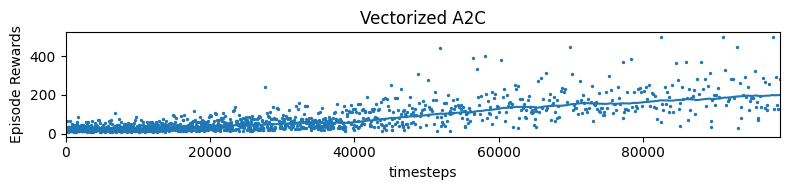

In [50]:
log_dir = "/tmp/vectorized/"
os.makedirs(log_dir, exist_ok=True)  # we have to create this dir - it does not existenv =
eval_env = gym.make("CartPole-v1",render_mode="rgb_array")  # evaluation environment
vec_env = make_vec_env("CartPole-v1", n_envs=4, monitor_dir=log_dir)

batch_size = 64
lr = 1e-4
total_timesteps = 100000

vectorized_a2c = A2C(
    MlpPolicy, vec_env, learning_rate=lr, seed=SEED,
    verbose=1,
)
vectorized_a2c.learn(total_timesteps)
display(ipythondisplay.HTML(visualize_model(vectorized_a2c, env=eval_env)))
plot_results([log_dir], total_timesteps, "timesteps", "Vectorized A2C")
results = load_results(log_dir)
print(f"Max reward: {results.r.max()}")


## Zadanie 1.

Zbadaj wpływ kilku (liczba środowisk oraz co najmniej 3 inne) wybranych hiperparametrów na trenowanie i działanie modelu A2C (uwaga: oprócz zbadania należy rozumieć, do czego służy dany hiperparametr). Zapisz swoje wnioski i przygotuj wizualizacje uzyskiwanych rezultatów oraz animiacje działania modelu.


### Rozwiązanie

Zbadamy wpływ **czterech** hiperparametrów na uczenie i działanie modelu A2C w środowisku `CartPole-v1`:

| Hiperparametr | Co kontroluje | Domyślnie (A2C) |
|---|---|---|
| **`n_envs`** (liczba środowisk) | Ile równoległych kopii środowiska zbiera doświadczenia naraz. Efektywny rozmiar wsadu na aktualizację = `n_steps × n_envs`. Więcej środowisk → mniej skorelowane próbki i stabilniejszy gradient, ale więcej obliczeń. | - (env. pojedyncze) |
| **`learning_rate`** | Krok optymalizatora. Za duży → niestabilne/rozbieżne uczenie; za mały → wolna zbieżność. | `7e-4` |
| **`n_steps`** | Długość rolloutu (ile kroków na środowisko przed aktualizacją). Wpływa na obciążenie szacowania zwrotu (bias) vs wariancję oraz na efektywny rozmiar wsadu. | `5` |
| **`gamma`** | Współczynnik dyskontowania przyszłych nagród. Bliżej 1 → model bardziej "dalekowzroczny" (ceni odległe nagrody), niżej → krótkowzroczny. | `0.99` |

In [51]:
# --- Konfiguracja eksperymentów ---
from collections import OrderedDict

import pandas as pd
from stable_baselines3.common.monitor import load_results
from stable_baselines3.common.results_plotter import ts2xy

TOTAL_TIMESTEPS = 100000      # liczba kroków uczenia na pojedynczy model
N_EVAL_EPISODES = 100        # epizodów do oceny końcowej
BASE_LOG = "/tmp/zad1"
os.makedirs(BASE_LOG, exist_ok=True)


def moving_average(values, window=20):
    """Wygładzanie średnią kroczącą (do czytelnych krzywych uczenia)."""
    values = np.asarray(values, dtype=float)
    if len(values) < window:
        return values
    weights = np.ones(window) / window
    return np.convolve(values, weights, mode="valid")


def get_frames(model, max_steps=300):
    """Zbiera klatki RGB z rolloutu modelu (odporne na gym/gymnasium oraz VecEnv)."""
    env = model.get_env()                      # SB3 VecEnv
    obs = env.reset()
    frames = []
    for _ in range(max_steps):
        try:
            img = env.render(mode="rgb_array")  # VecEnv API (zwraca pojedynczy obraz)
        except TypeError:
            img = env.render()
        if isinstance(img, (list, tuple)):
            img = img[0]
        frames.append(img)
        action, _ = model.predict(obs, deterministic=True)
        step = env.step(action)
        obs, _, done = step[0], step[1], step[2]
        if np.any(done):
            obs = env.reset()
    return frames


def animate(frames, interval=40):
    """Tworzy animację jshtml z listy klatek."""
    fig, ax = plt.subplots()
    ax.axis("off")
    im = ax.imshow(frames[0])
    plt.close()
    anim = animation.FuncAnimation(
        fig=fig,
        func=lambda i: im.set_data(frames[i]),
        frames=range(len(frames)),
        interval=interval,
        blit=False,
    )
    return anim.to_jshtml()


def train_a2c(name, n_envs=1, **a2c_kwargs):
    """Trenuje jeden model A2C z danym configiem i zwraca (model, wyniki, df_uczenia)."""
    log_dir = os.path.join(BASE_LOG, name)
    os.makedirs(log_dir, exist_ok=True)
    # czyścimy stare logi monitora, by load_results nie mieszał przebiegów
    for f in os.listdir(log_dir):
        if f.endswith("monitor.csv"):
            os.remove(os.path.join(log_dir, f))

    vec_env = make_vec_env(
        "CartPole-v1", n_envs=n_envs, seed=SEED,
        monitor_dir=log_dir, env_kwargs={"render_mode": "rgb_array"},
    )
    model = A2C(MlpPolicy, vec_env, seed=SEED, verbose=0, **a2c_kwargs)
    model.learn(TOTAL_TIMESTEPS)

    mean_r, std_r = evaluate_policy(model, vec_env, n_eval_episodes=N_EVAL_EPISODES)
    df = load_results(log_dir)
    print(f"[{name:<22}] reward = {mean_r:6.2f} +/- {std_r:5.2f}")
    return model, (mean_r, std_r), df


def plot_learning_curves(runs, title):
    """runs: dict label -> df; rysuje wygładzone krzywe uczenia (nagroda vs kroki)."""
    plt.figure(figsize=(9, 5))
    for label, df in runs.items():
        if len(df) == 0:
            continue
        x, y = ts2xy(df, "timesteps")
        y_s = moving_average(y, window=min(20, max(1, len(y) // 2)))
        x_s = x[len(x) - len(y_s):]
        plt.plot(x_s, y_s, label=label)
    plt.xlabel("Liczba kroków (timesteps)")
    plt.ylabel("Nagroda w epizodzie (śr. krocząca)")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def plot_final_rewards(scores, title):
    """scores: dict label -> (mean, std); słupkowy wykres końcowej nagrody."""
    labels = list(scores.keys())
    means = [scores[k][0] for k in labels]
    stds = [scores[k][1] for k in labels]
    plt.figure(figsize=(9, 4))
    plt.bar(range(len(labels)), means, yerr=stds, capsize=4, alpha=0.8)
    plt.xticks(range(len(labels)), labels, rotation=20, ha="right")
    plt.ylabel(f"Śr. nagroda ({N_EVAL_EPISODES} epizodów)")
    plt.title(title)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


[nenvs_1               ] reward = 500.00 +/-  0.00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[nenvs_2               ] reward = 500.00 +/-  0.00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[nenvs_4               ] reward = 500.00 +/-  0.00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[nenvs_8               ] reward = 124.41 +/-  6.16


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[nenvs_16              ] reward = 443.21 +/- 88.84


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


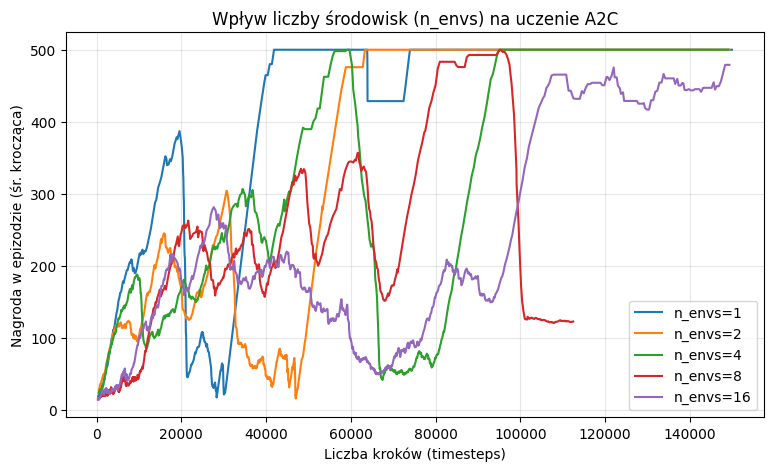

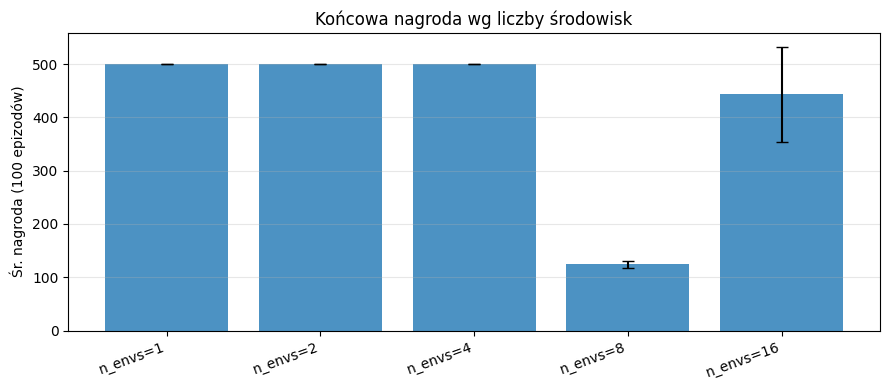

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [52]:
# === Eksperyment 1: liczba środowisk (n_envs) ===
# Więcej równoległych środowisk -> większy, mniej skorelowany wsad na aktualizację.
nenvs_curves, nenvs_scores, nenvs_models = OrderedDict(), OrderedDict(), {}
for n in [1, 2, 4, 8, 16]:
    label = f"n_envs={n}"
    model, score, df = train_a2c(f"nenvs_{n}", n_envs=n)
    nenvs_curves[label], nenvs_scores[label], nenvs_models[label] = df, score, model

plot_learning_curves(nenvs_curves, "Wpływ liczby środowisk (n_envs) na uczenie A2C")
plot_final_rewards(nenvs_scores, "Końcowa nagroda wg liczby środowisk")


[lr_1e-05              ] reward =  61.60 +/- 16.76


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[lr_1e-04              ] reward = 446.98 +/- 87.01


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[lr_7e-04              ] reward = 500.00 +/-  0.00


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[lr_1e-02              ] reward =   9.29 +/-  0.71


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[lr_1e-01              ] reward =   9.35 +/-  0.70


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


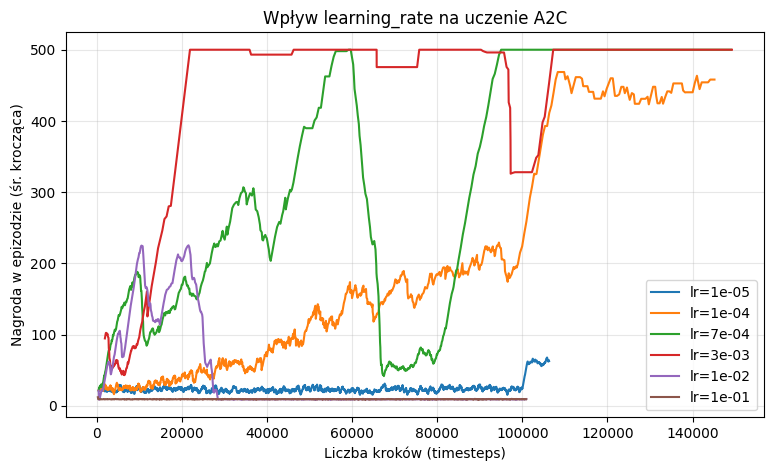

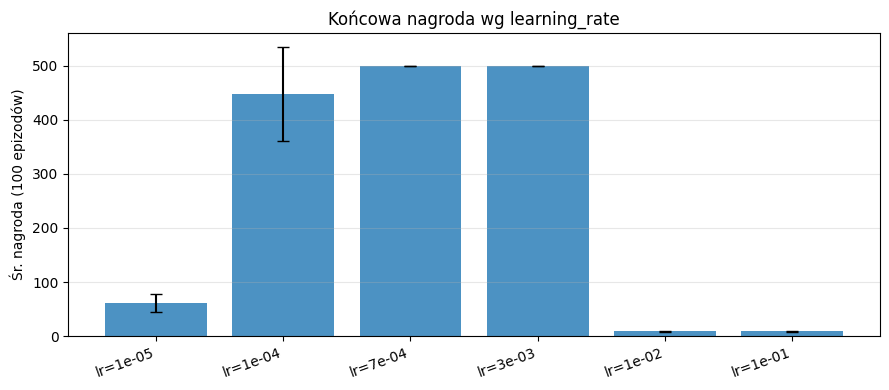

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [53]:
# === Eksperyment 2: learning_rate ===
# Za duży LR -> niestabilność; za mały -> wolna zbieżność. (n_envs=4 jako stała baza.)
lr_curves, lr_scores = OrderedDict(), OrderedDict()
for lr in [1e-5, 1e-4, 7e-4, 3e-3, 1e-2, 1e-1]:
    label = f"lr={lr:.0e}"
    _, score, df = train_a2c(f"lr_{lr:.0e}", n_envs=4, learning_rate=lr)
    lr_curves[label], lr_scores[label] = df, score

plot_learning_curves(lr_curves, "Wpływ learning_rate na uczenie A2C")
plot_final_rewards(lr_scores, "Końcowa nagroda wg learning_rate")


[nsteps_1              ] reward =   9.42 +/-  0.78


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[nsteps_5              ] reward = 500.00 +/-  0.00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[nsteps_16             ] reward = 500.00 +/-  0.00


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[nsteps_128            ] reward = 492.51 +/- 29.92


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[nsteps_512            ] reward = 476.20 +/- 54.41


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


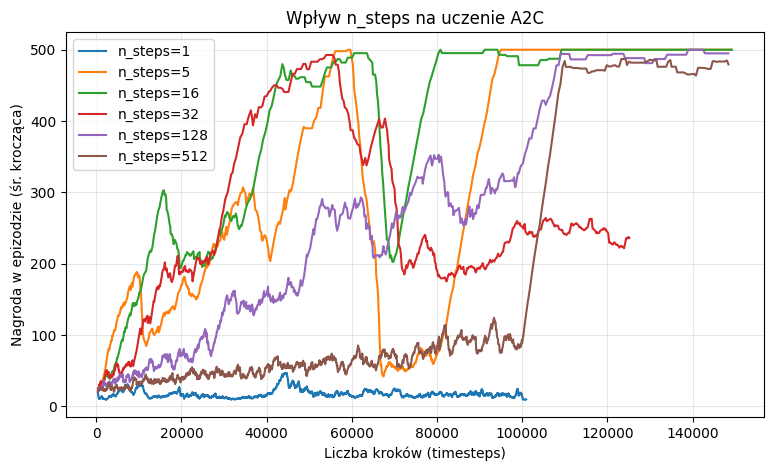

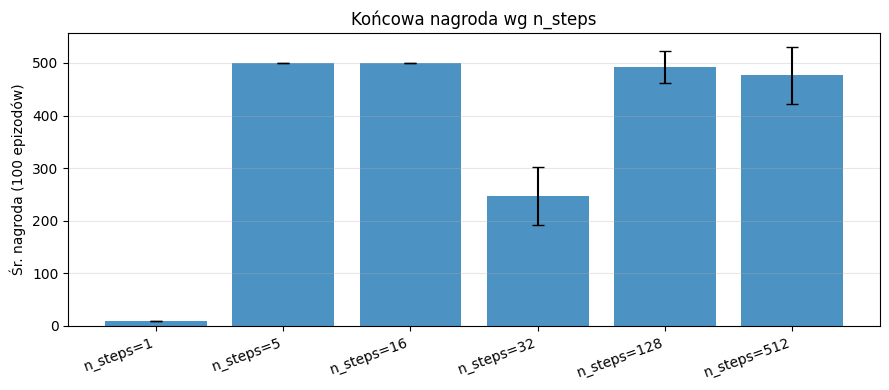

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [54]:
# === Eksperyment 3: n_steps (długość rolloutu) ===
# Dłuższy rollout -> mniejszy bias szacowania zwrotu i większy efektywny wsad,
# ale rzadsze aktualizacje. (n_envs=4 jako stała baza.)
nsteps_curves, nsteps_scores = OrderedDict(), OrderedDict()
for ns in [1, 5, 16, 32, 128, 512]:
    label = f"n_steps={ns}"
    _, score, df = train_a2c(f"nsteps_{ns}", n_envs=4, n_steps=ns)
    nsteps_curves[label], nsteps_scores[label] = df, score

plot_learning_curves(nsteps_curves, "Wpływ n_steps na uczenie A2C")
plot_final_rewards(nsteps_scores, "Końcowa nagroda wg n_steps")


[gamma_0.5             ] reward = 129.72 +/-  9.55


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[gamma_0.8             ] reward = 377.40 +/- 60.74


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[gamma_0.9             ] reward = 464.05 +/- 61.68


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[gamma_0.999           ] reward = 419.93 +/- 134.57


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[gamma_1.0             ] reward = 118.99 +/- 84.01


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


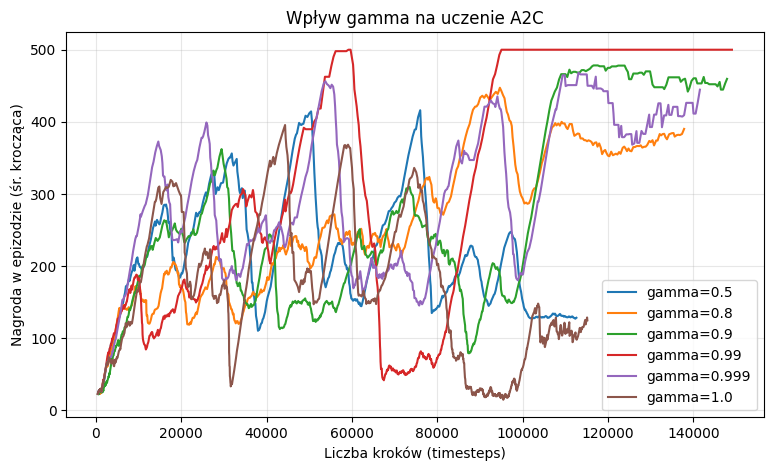

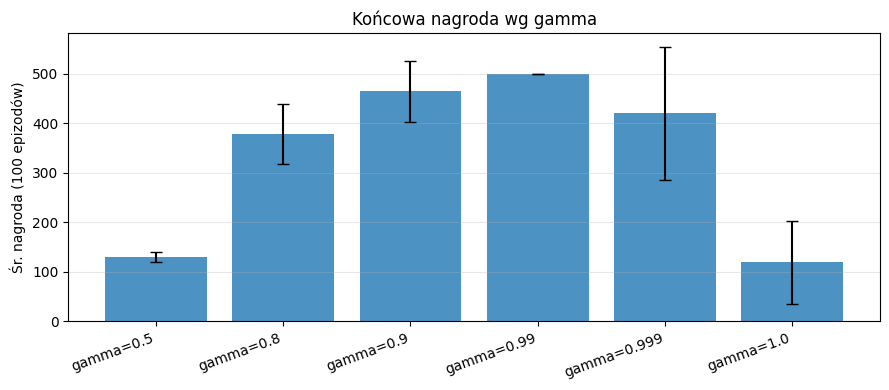

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [55]:
# === Eksperyment 4: gamma (dyskontowanie) ===
# Niska gamma -> krótkowzroczność; zbyt wysoka -> duża wariancja zwrotów.
# W CartPole liczy się utrzymanie drążka jak najdłużej, więc dalekowzroczność pomaga.
gamma_curves, gamma_scores = OrderedDict(), OrderedDict()
for g in [0.5, 0.8, 0.9, 0.99, 0.999, 1.0]:
    label = f"gamma={g}"
    _, score, df = train_a2c(f"gamma_{g}", n_envs=4, gamma=g)
    gamma_curves[label], gamma_scores[label] = df, score

plot_learning_curves(gamma_curves, "Wpływ gamma na uczenie A2C")
plot_final_rewards(gamma_scores, "Końcowa nagroda wg gamma")


In [56]:
# === Animacja działania najlepszego modelu (najwięcej środowisk) ===
best_label = max(nenvs_scores, key=lambda k: nenvs_scores[k][0])
print(f"Najlepszy model ze sweepu n_envs: {best_label} "
      f"(reward={nenvs_scores[best_label][0]:.2f})")
best_model = nenvs_models[best_label]
display(ipythondisplay.HTML(animate(get_frames(best_model, max_steps=300))))


Najlepszy model ze sweepu n_envs: n_envs=1 (reward=500.00)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Wnioski

Maksymalna możliwa nagroda w CartPole-v1 to 500. Dla każdego hiperparametru sprawdziłem też wartości
graniczne, żeby zobaczyć, kiedy model przestaje działać.

**Liczba środowisk (`n_envs`).** Dla 1, 2 i 4 środowisk model osiągnął maksymalne 500. Ciekawe, że przy
`n_envs=8` wynik mocno spadł (124), a przy 16 podniósł się do 443 - czyli wbrew intuicji więcej środowisk
nie dało lepszego wyniku. Wynika to z tego, że przy stałym budżecie kroków więcej środowisk = mniej
aktualizacji sieci, więc model nie zdążył się dotrenować. Krótko: liczba środowisk głównie przyspiesza
zbieranie danych, ale trzeba zwiększyć też liczbę kroków, żeby to wykorzystać.

**`learning_rate`.** Najlepiej widać tu „okno" działania. `7e-4` i `3e-3` dały 500, ale skrajności zawiodły:
przy `1e-5` uczenie było za wolne (62), a przy `1e-2` i `1e-1` krok był za duży i model w ogóle się nie nauczył
(~9, czyli poziom losowy). Najbezpieczniejsze są wartości w okolicy domyślnej `7e-4`.

**`n_steps`.** `5` i `16` dały 500. `n_steps=1` całkowicie zepsuło uczenie (9 - rollout za krótki, ogromny szum).
Dłuższe rollouty (128, 512) też działały dobrze (~480–493), ale `n_steps=32` wypadło słabiej (247) - prawdopodobnie
przez mniejszą liczbę aktualizacji i zwykłą losowość pojedynczego przebiegu. Wniosek: zbyt krótki rollout szkodzi
najbardziej, a umiarkowane wartości są bezpieczne.

**`gamma`.** Tu zależność jest najładniejsza: 0.5 → 130, 0.8 → 377, 0.9 → 464, **0.99 → 500**, potem znowu spadek
0.999 → 420 i 1.0 → 119. Za niska gamma (krótkowzroczność) i brak dyskontowania (1.0, duża wariancja) wyraźnie
psują wynik. Najlepiej działa `gamma=0.99`.

**Podsumowanie.** Najlepsze ustawienia w moich eksperymentach to `learning_rate≈7e-4`, `n_steps` rzędu 5–16
oraz `gamma=0.99`; liczbę środowisk trzeba dobierać razem z liczbą kroków uczenia. Wartości graniczne potwierdziły,
że każdy hiperparametr ma zakres, poza którym model uczy się wolno albo wcale (najwyraźniej `lr` i `gamma`).

## Zadanie 2.

Jedną z zalet metod *policy gradient* oraz aktor-krytyk jest fakt, że dzięki zastosowaniu modelu strategii możliwe jest działanie modelu w środowiskach z ciągłą przestrzenią akcji. Wybierz dowolne środowisko z ciągłą przestrzenią akcji spośród dostępnych w bibliotece [Gym](https://gym.openai.com/envs) i zastosuj na nim model A2C. Dostrój hiperparametry modelu tak, aby uzyskać poprawne działanie. Zapoznaj się z definicją funkcji nagrody w środowisku.

W przypadku wyboru środowiska z obserwacjami wizualnymi zmodyfikuj wykorzystany model strategii. (Uwaga: proszę mieć na uwadze, że trenowanie modeli A2C dla środowisk o ciągłej przestrzeni akcji jest bardziej złożone obliczeniowo - próba wytrenowania modelu dla bardzo złożonego środowiska może zająć dłużej).


### Rozwiązanie

**Wybrane środowisko: `Pendulum-v1`** - klasyczny problem sterowania z **ciągłą przestrzenią akcji**.

| Element | Opis |
|---|---|
| **Obserwacja** | `Box([-1,-1,-8], [1,1,8], shape=(3,))` = `[cos θ, sin θ, θ̇]` (kąt zakodowany jako cos/sin). |
| **Akcja** | `Box(-2.0, 2.0, shape=(1,))` - pojedynczy **ciągły** moment obrotowy (torque). To czyni środowisko ciągłym i wymusza politykę gaussowską (DiagGaussian). |
| **Funkcja nagrody** | `r = -(θ² + 0.1·θ̇² + 0.001·akcja²)`, gdzie θ ∈ [-π, π], 0 = pozycja pionowa (do góry). |
| **Zakres nagrody/krok** | od `≈ -16.27` (poziomo, duża prędkość, duży moment) do `0` (idealnie w pionie, bez ruchu i siły). Nagroda zawsze ≤ 0. |
| **Epizod** | brak warunku `terminated`; epizod **truncated po 200 krokach** (TimeLimit). Najlepszy zwrot ≈ 0, losowy agent ≈ -1200…-1600. |

**Interpretacja funkcji nagrody.** Kara rośnie z (1) odchyleniem od pionu (`θ²` - najważniejszy człon), (2) prędkością
kątową (`0.1·θ̇²` - premiuje spokojne, stabilne trzymanie) oraz (3) zużyciem energii (`0.001·akcja²` - drobna kara za
duże momenty). Agent ma więc jak najszybciej postawić wahadło pionowo i utrzymać je **nieruchomo, minimalnym wysiłkiem**.
Dobrze wytrenowany agent osiąga średnią nagrodę **≈ -150…-250** (referencyjny model SB3: -203 ± 126).

**Dlaczego A2C wymaga strojenia na Pendulum.** "Goły" A2C słabo radzi sobie z ciągłym sterowaniem. Kluczowe są:
- **`VecNormalize`** - normalizacja obserwacji i zwrotów (A2C jest wrażliwy na skalę wejść/zwrotów);
- **`use_sde=True`** (gSDE) - stanowo-zależna eksploracja, gładsza i skuteczniejsza dla akcji ciągłych;
- **`log_std_init=-2`** - start z małym odchyleniem std akcji (mniej chaotyczna eksploracja na początku);
- niskie **`gamma=0.9`** (krótki, 200-krokowy horyzont), wiele środowisk (`n_envs=8`) i krótki rollout (`n_steps=8`).

Hiperparametry poniżej pochodzą z dostrojonej konfiguracji [RL Baselines3 Zoo](https://github.com/DLR-RM/rl-baselines3-zoo).

In [57]:
# === Dostrojony A2C na Pendulum-v1 (ciągła przestrzeń akcji) ===
from stable_baselines3.common.vec_env import VecNormalize

# Liczba kroków: 3e5 to rozsądny kompromis czas/jakość na Colab CPU (~kilka-kilkanaście min).
# Dla pełnej zbieżności (~-200) ustaw 1_000_000 (config z RL Zoo) - kosztem dłuższego czasu.
PENDULUM_TIMESTEPS = 1_000_000


def linear_schedule(initial_value):
    """Liniowy harmonogram LR: maleje od initial_value do 0 wraz z postępem treningu."""
    def func(progress_remaining):   # progress_remaining: 1.0 -> 0.0
        return progress_remaining * initial_value
    return func


pend_log = "/tmp/zad2_pendulum/"
os.makedirs(pend_log, exist_ok=True)

# 8 równoległych środowisk + normalizacja obserwacji i zwrotów (kluczowe dla A2C tutaj).
pend_env = make_vec_env(
    "Pendulum-v1", n_envs=8, seed=SEED,
    monitor_dir=pend_log, env_kwargs={"render_mode": "rgb_array"},
)
pend_env = VecNormalize(pend_env, norm_obs=True, norm_reward=True, clip_obs=10.0)

pendulum_a2c = A2C(
    MlpPolicy, pend_env,
    learning_rate=linear_schedule(7e-4),
    n_steps=8,
    gamma=0.9,
    gae_lambda=0.9,
    ent_coef=0.0,
    vf_coef=0.4,
    max_grad_norm=0.5,
    use_sde=True,                                   # gSDE - eksploracja dla akcji ciągłych
    use_rms_prop=True,
    normalize_advantage=False,
    policy_kwargs=dict(log_std_init=-2, ortho_init=False),
    seed=SEED, verbose=1,
)
pendulum_a2c.learn(PENDULUM_TIMESTEPS)


Using cpu device
-------------------------------------
| rollout/              |           |
|    ep_len_mean        | 200       |
|    ep_rew_mean        | -1.36e+03 |
| time/                 |           |
|    fps                | 4363      |
|    iterations         | 100       |
|    time_elapsed       | 1         |
|    total_timesteps    | 6400      |
| train/                |           |
|    entropy_loss       | -0.162    |
|    explained_variance | 0.95      |
|    learning_rate      | 0.000696  |
|    n_updates          | 99        |
|    policy_loss        | 0.00161   |
|    std                | 0.137     |
|    value_loss         | 8.74e-05  |
-------------------------------------
-------------------------------------
| rollout/              |           |
|    ep_len_mean        | 200       |
|    ep_rew_mean        | -1.36e+03 |
| time/                 |           |
|    fps                | 4517      |
|    iterations         | 200       |
|    time_elapsed       | 2      

Pendulum-v1 | średnia nagroda (prawdziwa): -169.79 +/- 112.99
Odniesienie: losowy agent ~ -1200..-1600 ;  dobry agent ~ -150..-250


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


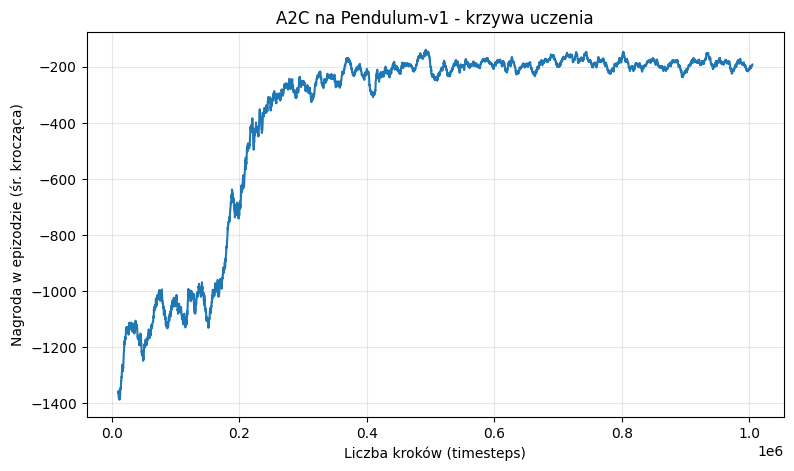

In [58]:
# === Ewaluacja: PRAWDZIWA (nieznormalizowana) nagroda ===
# Pułapka VecNormalize: trzeba zamrozić statystyki i wyłączyć normalizację nagrody,
# inaczej evaluate_policy zwróci nagrodę znormalizowaną (nieporównywalną z ~-200).
eval_env = pendulum_a2c.get_env()
eval_env.training = False        # zamroź running mean/std
eval_env.norm_reward = False     # zwracaj prawdziwą nagrodę

mean_r, std_r = evaluate_policy(pendulum_a2c, eval_env, n_eval_episodes=20)
print(f"Pendulum-v1 | średnia nagroda (prawdziwa): {mean_r:.2f} +/- {std_r:.2f}")
print("Odniesienie: losowy agent ~ -1200..-1600 ;  dobry agent ~ -150..-250")

# Krzywa uczenia z logów monitora
df = load_results(pend_log)
if len(df) > 0:
    x, y = ts2xy(df, "timesteps")
    y_s = moving_average(y, window=min(50, max(1, len(y) // 2)))
    x_s = x[len(x) - len(y_s):]
    plt.figure(figsize=(9, 5))
    plt.plot(x_s, y_s)
    plt.xlabel("Liczba kroków (timesteps)")
    plt.ylabel("Nagroda w epizodzie (śr. krocząca)")
    plt.title("A2C na Pendulum-v1 - krzywa uczenia")
    plt.grid(alpha=0.3)
    plt.show()


In [59]:
# === Animacja działania wytrenowanego A2C na Pendulum ===
# Używamy env modelu (VecNormalize) - obserwacje są automatycznie normalizowane,
# a render() i tak pokazuje stan symulatora (normalizacja nie wpływa na obraz).
vis_env = pendulum_a2c.get_env()
vis_env.training = False
vis_env.norm_reward = False

obs = vis_env.reset()
frames = []
for _ in range(200):             # Pendulum truncuje po 200 krokach
    frames.append(vis_env.get_images()[0])
    action, _ = pendulum_a2c.predict(obs, deterministic=True)
    obs, reward, done, info = vis_env.step(action)   # VecEnv: 4-krotka, auto-reset

display(ipythondisplay.HTML(animate(frames, interval=40)))


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
